# rice leaf

In [ ]:
import os
import json
import copy
import time

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import DataLoader, WeightedRandomSampler

import torchvision
import torchvision.models as tv_models
import torchvision.transforms.v2 as T               
from torchvision.datasets import ImageFolder

from PIL import Image
import os
import random

import kagglehub


In [ ]:
path=kagglehub.dataset_download("dedeikhsandwisaputra/rice-leafs-disease-dataset")
print(f"Dataset path: {path}")

In [ ]:
base_dir =os.path.join(path,'RiceLeafsDisease')
train_dir =os.path.join(base_dir,'train')
val_dir= os.path.join(base_dir,'validation')

In [4]:
len(os.listdir(train_dir)), len(os.listdir(val_dir))

(7, 7)

In [ ]:
from torchvision.datasets import CIFAR100

ood_train_dir = os.path.join(train_dir, "non_rice_leaf")
ood_val_dir   = os.path.join(val_dir, "non_rice_leaf")

os.makedirs(ood_train_dir, exist_ok=True)
os.makedirs(ood_val_dir, exist_ok=True)

cifar = CIFAR100(
    root="./cifar100",
    train=True,
    download=True
)


In [12]:

all_images = [img for img, _ in cifar]

random.seed(42)
random.shuffle(all_images)

train_imgs = all_images[:350]
val_imgs   = all_images[350:438]

print(f"Saving {len(train_imgs)} diverse images to {ood_train_dir}...")

for i, img in enumerate(train_imgs):
    img.save(os.path.join(ood_train_dir, f"ood_{i:04d}.jpg"))

print(f"Saving {len(val_imgs)} diverse images to {ood_val_dir}...")

for i, img in enumerate(val_imgs):
    img.save(os.path.join(ood_val_dir, f"ood_{i:04d}.jpg"))

print("OOD data added successfully")

print("Train OOD images:", len(os.listdir(ood_train_dir)))
print("Val OOD images  :", len(os.listdir(ood_val_dir)))

Saving 350 diverse images to C:\Users\aksha\.cache\kagglehub\datasets\dedeikhsandwisaputra\rice-leafs-disease-dataset\versions\1\RiceLeafsDisease\train\non_rice_leaf...
Saving 88 diverse images to C:\Users\aksha\.cache\kagglehub\datasets\dedeikhsandwisaputra\rice-leafs-disease-dataset\versions\1\RiceLeafsDisease\validation\non_rice_leaf...
OOD data added successfully
Train OOD images: 350
Val OOD images  : 88


In [21]:
IMG_SIZE   = 224      
BATCH_SIZE = 32
CONFIDENCE_THRESHOLD = 0.70   


torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\nUsing device: {DEVICE}")


Using device: cuda


In [15]:
_probe = ImageFolder(train_dir)
class_names = _probe.classes            
NUM_CLASSES  = len(class_names)
NON_RICE_IDX = (class_names.index('non_rice_leaf')
                if 'non_rice_leaf' in class_names else None)
del _probe

print(f"\n{'='*60}")
print(f"Classes ({NUM_CLASSES}): {class_names}")
print(f"OOD class index: {NON_RICE_IDX}")
print(f"{'='*60}\n")

for cls in class_names:
    train_cnt = len(os.listdir(os.path.join(train_dir, cls)))
    val_cnt   = len(os.listdir(os.path.join(val_dir,   cls)))
    print(f"{cls:<30} Train: {train_cnt:>4}  Val: {val_cnt:>4}")


Classes (7): ['bacterial_leaf_blight', 'brown_spot', 'healthy', 'leaf_blast', 'leaf_scald', 'narrow_brown_spot', 'non_rice_leaf']
OOD class index: 6

bacterial_leaf_blight          Train:  350  Val:   88
brown_spot                     Train:  350  Val:   88
healthy                        Train:  350  Val:   88
leaf_blast                     Train:  350  Val:   88
leaf_scald                     Train:  350  Val:   88
narrow_brown_spot              Train:  350  Val:   88
non_rice_leaf                  Train:  350  Val:   88


In [18]:
import torch
from torchvision.datasets import ImageFolder
import torchvision.transforms.v2 as T
from torch.utils.data import DataLoader

dataset = ImageFolder(
    train_dir,
    transform=T.Compose([
        T.Resize((224, 224)),
        T.ToImage(),
        T.ToDtype(torch.float32, scale=True)
    ])
)

loader = DataLoader(
    dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2
)

mean = torch.zeros(3)
std = torch.zeros(3)
total_pixels = 0

for images, _ in loader:
    # images: (B,C,H,W)

    b, c, h, w = images.shape
    pixels = b * h * w

    mean += images.sum(dim=[0, 2, 3])
    std += (images ** 2).sum(dim=[0, 2, 3])

    total_pixels += pixels

mean /= total_pixels

std = torch.sqrt(
    (std / total_pixels) - mean**2
)

print("Mean:", mean)
print("Std :", std)

Mean: tensor([0.8051, 0.8016, 0.7474])
Std : tensor([0.2393, 0.2317, 0.3203])


In [19]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]


train_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),

  
    T.ToImage(),
    T.ToDtype(torch.float32, scale=True),

    T.RandomHorizontalFlip(p=0.5),
    T.RandomVerticalFlip(p=0.5),
  
    T.RandomRotation(degrees=25),

    T.RandomAffine(
        degrees=0,
        scale=(0.9, 1.1)
    ),

    T.RandomAffine(
        degrees=0,
        translate=(0.08, 0.08)
    ),

    T.ColorJitter(
        brightness=0.15,
        contrast=0.15
    ),

    T.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    ),
])


val_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToImage(),
    T.ToDtype(torch.float32, scale=True),
    T.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    ),
])


train_dataset = ImageFolder(
    root=train_dir,
    transform=train_transform
)

val_dataset = ImageFolder(
    root=val_dir,
    transform=val_transform
)


print("Classes:", train_dataset.classes)
print("Class-to-index:", train_dataset.class_to_idx)

Classes: ['bacterial_leaf_blight', 'brown_spot', 'healthy', 'leaf_blast', 'leaf_scald', 'narrow_brown_spot', 'non_rice_leaf']
Class-to-index: {'bacterial_leaf_blight': 0, 'brown_spot': 1, 'healthy': 2, 'leaf_blast': 3, 'leaf_scald': 4, 'narrow_brown_spot': 5, 'non_rice_leaf': 6}


In [ ]:
class_counts   = np.array([len(os.listdir(os.path.join(train_dir, c)))
                            for c in class_names])
total_samples  = class_counts.sum()

sample_weights = np.array([1.0 / class_counts[label]
                            for _, label in train_dataset.samples])
sampler = WeightedRandomSampler(
    weights=torch.DoubleTensor(sample_weights),
    num_samples=len(train_dataset),
    replacement=True
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=sampler,       
    num_workers=2,
    pin_memory=True if torch.cuda.is_available() else False,
    drop_last=True
)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True if torch.cuda.is_available() else False
)

print(f"\nTraining batches  : {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")


Training batches  : 76
Validation batches: 20


In [ ]:
print(f"\nClass weights (loss):")
class_weight_vals = torch.tensor(
    [total_samples / (NUM_CLASSES * cnt) for cnt in class_counts],
    dtype=torch.float32
).to(DEVICE)

for i, (cls, w) in enumerate(zip(class_names, class_weight_vals.cpu().numpy())):
    print(f"  [{i}] {cls:<30} weight={w:.3f}")


images_sample, _ = next(iter(train_loader))
print(f"\nPost-preprocess pixel range:")
print(f"  Min : {images_sample.min().item():.3f}")
print(f"  Max : {images_sample.max().item():.3f}")
print(f"  Mean: {images_sample.mean().item():.3f}")
print("should be roughly in [-2.1, 2.6] (ImageNet normalised)")


Class weights (loss):
  [0] bacterial_leaf_blight          weight=1.000
  [1] brown_spot                     weight=1.000
  [2] healthy                        weight=1.000
  [3] leaf_blast                     weight=1.000
  [4] leaf_scald                     weight=1.000
  [5] narrow_brown_spot              weight=1.000
  [6] non_rice_leaf                  weight=1.000

Post-preprocess pixel range:
  Min : -2.118
  Max : 2.640
  Mean: 0.866
should be roughly in [-2.1, 2.6] (ImageNet normalised)


In [ ]:
class RiceEfficientNetB3(nn.Module):

    def __init__(self, num_classes: int):
        super().__init__()


        backbone = tv_models.efficientnet_b3(
            weights=tv_models.EfficientNet_B3_Weights.DEFAULT
        )

        self.features = backbone.features
        self.avgpool = backbone.avgpool

        feature_dim = backbone.classifier[1].in_features

        for param in self.features.parameters():
            param.requires_grad = False

        self.classifier = nn.Sequential(
            # BN1
            nn.BatchNorm1d(feature_dim),
            nn.Dropout(0.35),

            # Dense 512
            nn.Linear(feature_dim, 512),
            nn.ReLU(inplace=True),
            nn.BatchNorm1d(512),
            nn.Dropout(0.40),

            # Dense 256
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.30),

            # Output
            nn.Linear(256, num_classes)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x


    def freeze_backbone(self):

        for param in self.features.parameters():
            param.requires_grad = False

    def unfreeze_top_blocks(self, num_blocks: int = 3):
   
        # First unfreeze everything
        for param in self.features.parameters():
            param.requires_grad = True

        # Re-freeze early blocks
        freeze_until = len(self.features) - num_blocks

        for i, block in enumerate(self.features):
            if i < freeze_until:
                for param in block.parameters():
                    param.requires_grad = False

        trainable = sum(
            p.numel()
            for p in self.features.parameters()
            if p.requires_grad
        )

        frozen = sum(
            p.numel()
            for p in self.features.parameters()
            if not p.requires_grad
        )

        print(
            f"\nUnfreezing last {num_blocks} feature blocks "
            f"(blocks {freeze_until}-{len(self.features)-1})."
        )
        print(f"Backbone trainable params : {trainable:,}")
        print(f"Backbone frozen params    : {frozen:,}")

    def train(self, mode: bool = True):
 
        super().train(mode)

        for module in self.features.modules():
            if isinstance(module, nn.BatchNorm2d):
                module.eval()

        return self

In [25]:
model = RiceEfficientNetB3(num_classes=NUM_CLASSES).to(DEVICE)

Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to C:\Users\aksha/.cache\torch\hub\checkpoints\efficientnet_b3_rwightman-b3899882.pth


100%|██████████| 47.2M/47.2M [00:04<00:00, 10.4MB/s]


In [26]:
loss_fn = nn.CrossEntropyLoss(
    label_smoothing=0.10,
    weight=class_weight_vals
)

In [27]:
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\n{'='*60}")
print(f"MODEL: EfficientNetB3_RiceV2 (PyTorch)")
print(f"Total parameters : {total_params:,}")
print(f"Trainable parameters : {trainable_params:,}")
print(f"{'='*60}")


MODEL: EfficientNetB3_RiceV2 (PyTorch)
Total parameters : 11,620,399
Trainable parameters : 924,167


In [28]:
History = {
    'accuracy': [], 'val_accuracy': [],
    'loss': [],     'val_loss': []
}

In [ ]:
def run_epoch(loader: DataLoader, model: nn.Module,
              loss_fn: nn.Module, optimizer=None,
              phase: str = 'train') -> tuple[float, float]:

    is_training = (phase == 'train')
    model.train(is_training)      

    running_loss   = 0.0
    running_correct = 0
    total_samples  = 0


    ctx = torch.enable_grad() if is_training else torch.no_grad()

    with ctx:
        for images, labels in loader:
            images = images.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)

            if is_training:
                optimizer.zero_grad()

            logits = model(images)                       
            loss   = loss_fn(logits, labels)              

            if is_training:
                loss.backward()
                optimizer.step()

            # Accuracy
            preds           = logits.argmax(dim=1)
            running_correct += (preds == labels).sum().item()
            running_loss    += loss.item() * images.size(0)
            total_samples   += images.size(0)

    epoch_loss = running_loss  / total_samples
    epoch_acc  = running_correct / total_samples
    return epoch_loss, epoch_acc

In [ ]:
def train_model(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    loss_fn: nn.Module,
    optimizer: optim.Optimizer,
    scheduler: ReduceLROnPlateau,
    num_epochs: int,
    patience: int,
    checkpoint_path: str,
    history: dict,
    stage_label: str = 'Stage'
) -> dict:

    best_val_acc    = -1.0
    best_state      = None
    patience_count  = 0

    print("\n===")
    print(f"{stage_label}")
    print("\n===")

    for epoch in range(1, num_epochs + 1):
        t0 = time.time()

        train_loss, train_acc = run_epoch(
            train_loader, model, loss_fn, optimizer, phase='train')
        val_loss, val_acc     = run_epoch(
            val_loader,   model, loss_fn, optimizer=None, phase='val')

   
        scheduler.step(val_loss)
        current_lr = optimizer.param_groups[0]['lr']

        elapsed = time.time() - t0
        print(f"Epoch {epoch:>3}/{num_epochs} "
              f"| loss: {train_loss:.4f}  acc: {train_acc*100:.2f}%"
              f" | val_loss: {val_loss:.4f}  val_acc: {val_acc*100:.2f}%"
              f" | lr: {current_lr:.2e}  [{elapsed:.0f}s]")

     
        history['loss'].append(train_loss)
        history['accuracy'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_accuracy'].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc   = val_acc
            best_state     = copy.deepcopy(model.state_dict())
            torch.save(best_state, checkpoint_path)
            print(f" Saved best model  val_acc={best_val_acc*100:.2f}%"
                  f" {checkpoint_path}")
            patience_count = 0
        else:
            patience_count += 1
            if patience_count >= patience:
                print(f"\n EarlyStopping triggered after {patience} epochs "
                      f"without improvement.")
                break

    if best_state is not None:
        model.load_state_dict(best_state)
        print(f"\n Restored best weights  val_acc={best_val_acc*100:.2f}%")

    print(f"\n {stage_label} Best Val Accuracy: {best_val_acc*100:.2f}%")
    return history

In [32]:
optimizer_s1 = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-3,
    weight_decay=1e-4
)

scheduler_s1 = ReduceLROnPlateau(
    optimizer_s1,
    mode='min',
    factor=0.5,
    patience=3,
    min_lr=1e-7
)

In [34]:
save_dir = "models"
os.makedirs(save_dir, exist_ok=True)

In [35]:
history_s1 = {'accuracy': [], 'val_accuracy': [], 'loss': [], 'val_loss': []}

history_s1 = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    loss_fn=loss_fn,
    optimizer=optimizer_s1,
    scheduler=scheduler_s1,
    num_epochs=20,
    patience=10,
    checkpoint_path=os.path.join(save_dir, 'stage1_best.pt'),
    history=history_s1,
    stage_label='STAGE 1: Transfer Learning (Frozen Backbone)'
)


===
STAGE 1: Transfer Learning (Frozen Backbone)

===
Epoch   1/20 | loss: 1.0064  acc: 74.84% | val_loss: 0.7500  val_acc: 85.88% | lr: 1.00e-03  [82s]
 Saved best model  val_acc=85.88% models\stage1_best.pt
Epoch   2/20 | loss: 0.8064  acc: 85.03% | val_loss: 0.7043  val_acc: 88.80% | lr: 1.00e-03  [166s]
 Saved best model  val_acc=88.80% models\stage1_best.pt
Epoch   3/20 | loss: 0.7680  acc: 86.60% | val_loss: 0.6660  val_acc: 91.23% | lr: 1.00e-03  [264s]
 Saved best model  val_acc=91.23% models\stage1_best.pt
Epoch   4/20 | loss: 0.7659  acc: 86.35% | val_loss: 0.6473  val_acc: 92.21% | lr: 1.00e-03  [147s]
 Saved best model  val_acc=92.21% models\stage1_best.pt
Epoch   5/20 | loss: 0.7517  acc: 87.38% | val_loss: 0.6462  val_acc: 91.23% | lr: 1.00e-03  [155s]
Epoch   6/20 | loss: 0.7365  acc: 88.24% | val_loss: 0.6320  val_acc: 92.21% | lr: 1.00e-03  [146s]
Epoch   7/20 | loss: 0.7031  acc: 90.46% | val_loss: 0.6552  val_acc: 92.05% | lr: 1.00e-03  [150s]
Epoch   8/20 | loss: 0

In [36]:
model.unfreeze_top_blocks(num_blocks=3)

optimizer_s2 = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-5,
    weight_decay=1e-4
)

scheduler_s2 = ReduceLROnPlateau(
    optimizer_s2,
    mode='min',
    factor=0.3,
    patience=5,
    min_lr=1e-8
)

history_s2 = {
    'accuracy': [],
    'val_accuracy': [],
    'loss': [],
    'val_loss': []
}

history_s2 = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    loss_fn=loss_fn,
    optimizer=optimizer_s2,
    scheduler=scheduler_s2,
    num_epochs=40,
    patience=15,
    checkpoint_path=os.path.join(save_dir, 'stage2_best.pt'),
    history=history_s2,
    stage_label='STAGE 2:Fine-tuning (Partial Unfreeze)'
)


Unfreezing last 3 feature blocks (blocks 6-8).
Backbone trainable params : 8,506,078
Backbone frozen params    : 2,190,154

===
STAGE 2:Fine-tuning (Partial Unfreeze)

===
Epoch   1/40 | loss: 0.6363  acc: 92.72% | val_loss: 0.5746  val_acc: 93.83% | lr: 1.00e-05  [111s]
 Saved best model  val_acc=93.83% models\stage2_best.pt
Epoch   2/40 | loss: 0.6203  acc: 93.75% | val_loss: 0.5638  val_acc: 94.81% | lr: 1.00e-05  [80s]
 Saved best model  val_acc=94.81% models\stage2_best.pt
Epoch   3/40 | loss: 0.6053  acc: 93.96% | val_loss: 0.5660  val_acc: 94.81% | lr: 1.00e-05  [57s]
Epoch   4/40 | loss: 0.6155  acc: 93.50% | val_loss: 0.5650  val_acc: 95.13% | lr: 1.00e-05  [54s]
 Saved best model  val_acc=95.13% models\stage2_best.pt
Epoch   5/40 | loss: 0.5880  acc: 94.98% | val_loss: 0.5686  val_acc: 93.83% | lr: 1.00e-05  [54s]
Epoch   6/40 | loss: 0.5873  acc: 95.44% | val_loss: 0.5496  val_acc: 96.27% | lr: 1.00e-05  [58s]
 Saved best model  val_acc=96.27% models\stage2_best.pt
Epoch   

In [54]:
print("\n===")
print("FINAL EVALUATION")
print("===")

train_loss_f, train_acc_f = run_epoch(train_loader, model, loss_fn, phase='val')
val_loss_f,   val_acc_f   = run_epoch(val_loader,   model, loss_fn, phase='val')

print(f"\nTraining Set   | Accuracy: {train_acc_f*100:.2f}%  Loss: {train_loss_f:.4f}")
print(f"Validation Set | Accuracy: {val_acc_f*100:.2f}%  Loss: {val_loss_f:.4f}")

gap = (train_acc_f - val_acc_f) * 100
print(f"GAP : {gap:.2f}")


===
FINAL EVALUATION
===

Training Set   | Accuracy: 99.30%  Loss: 0.4817
Validation Set | Accuracy: 98.54%  Loss: 0.4988
GAP : 0.76


In [38]:
pt_path = os.path.join(save_dir, 'rice_B3_pytorch.pt')
torch.save({
    'model_state_dict': model.state_dict(),
    'class_names': class_names,
    'confidence_threshold': CONFIDENCE_THRESHOLD,
    'num_classes': NUM_CLASSES,
    'img_size': IMG_SIZE
}, pt_path)
print(f"Saved PyTorch checkpoint : {pt_path}")

Saved PyTorch checkpoint : models\rice_B3_pytorch.pt


In [39]:
meta = {
    'class_names': class_names,
    'confidence_threshold': CONFIDENCE_THRESHOLD,
    'imagenet_mean': IMAGENET_MEAN,
    'imagenet_std': IMAGENET_STD,
    'img_size': IMG_SIZE
}
with open(os.path.join(save_dir, 'model_meta.json'), 'w') as f:
    json.dump(meta, f, indent=2)
print(f"Saved metadata: {os.path.join(save_dir, 'model_meta.json')}")

Saved metadata: models\model_meta.json


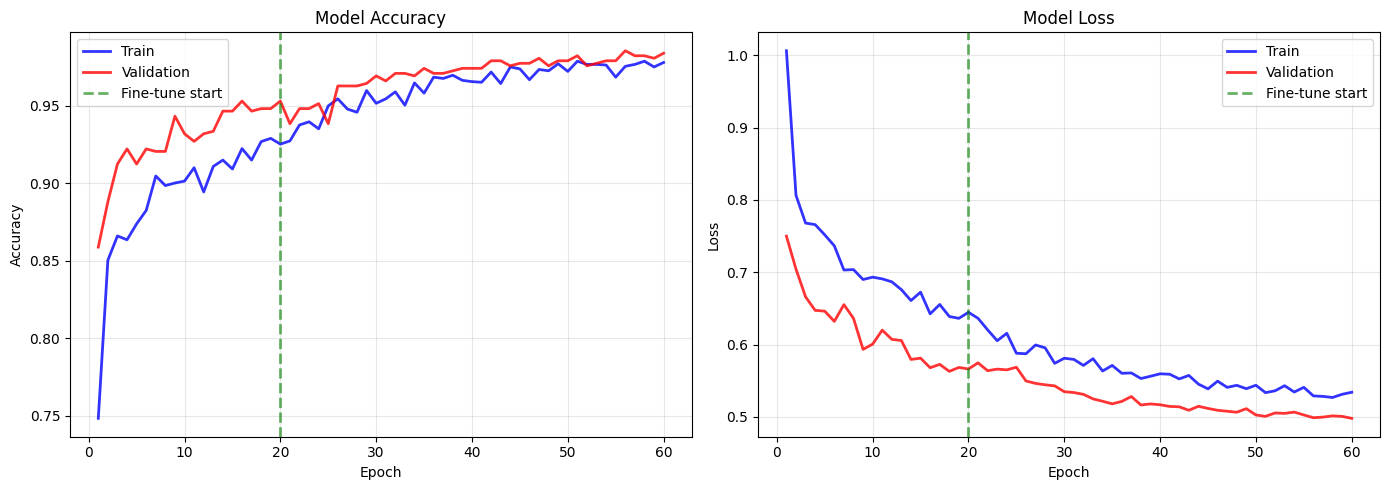

Best overall val accuracy: 98.54%


In [40]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

all_acc      = history_s1['accuracy']     + history_s2['accuracy']
all_val_acc  = history_s1['val_accuracy'] + history_s2['val_accuracy']
all_loss     = history_s1['loss']         + history_s2['loss']
all_val_loss = history_s1['val_loss']     + history_s2['val_loss']
s1_len       = len(history_s1['accuracy'])
epochs_range = range(1, len(all_acc) + 1)

ax1.plot(epochs_range, all_acc,     'b-', lw=2, label='Train',      alpha=0.8)
ax1.plot(epochs_range, all_val_acc, 'r-', lw=2, label='Validation', alpha=0.8)
ax1.axvline(s1_len, color='green', ls='--', lw=2, alpha=0.6, label='Fine-tune start')
ax1.set(xlabel='Epoch', ylabel='Accuracy', title='Model Accuracy')
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(epochs_range, all_loss,     'b-', lw=2, label='Train',      alpha=0.8)
ax2.plot(epochs_range, all_val_loss, 'r-', lw=2, label='Validation', alpha=0.8)
ax2.axvline(s1_len, color='green', ls='--', lw=2, alpha=0.6, label='Fine-tune start')
ax2.set(xlabel='Epoch', ylabel='Loss', title='Model Loss')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(save_dir, 'training_history.png'), dpi=300, bbox_inches='tight')
plt.show()
print(f"Best overall val accuracy: {max(all_val_acc)*100:.2f}%")

In [44]:
model.eval()
y_true_list, y_pred_raw_list = [], []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(DEVICE, non_blocking=True)
        logits = model(images)                          # (B, NUM_CLASSES) raw logits
        probs  = torch.softmax(logits, dim=1)           # (B, NUM_CLASSES) probabilities
        y_true_list.extend(labels.numpy())
        y_pred_raw_list.extend(probs.cpu().numpy())

y_true     = np.array(y_true_list)
y_pred_raw = np.array(y_pred_raw_list)

# Two-layer confidence-threshold rejection
NON_RICE_LABEL = (NON_RICE_IDX if NON_RICE_IDX is not None
                  else len(class_names) - 1)

y_pred = np.argmax(y_pred_raw, axis=1)


CLASSIFICATION REPORT
                       precision    recall  f1-score   support

bacterial_leaf_blight     1.0000    1.0000    1.0000        88
           brown_spot     0.9651    0.9432    0.9540        88
              healthy     0.9670    1.0000    0.9832        88
           leaf_blast     0.9655    0.9545    0.9600        88
           leaf_scald     1.0000    1.0000    1.0000        88
    narrow_brown_spot     1.0000    1.0000    1.0000        88
        non_rice_leaf     1.0000    1.0000    1.0000        88

             accuracy                         0.9854       616
            macro avg     0.9854    0.9854    0.9853       616
         weighted avg     0.9854    0.9854    0.9853       616



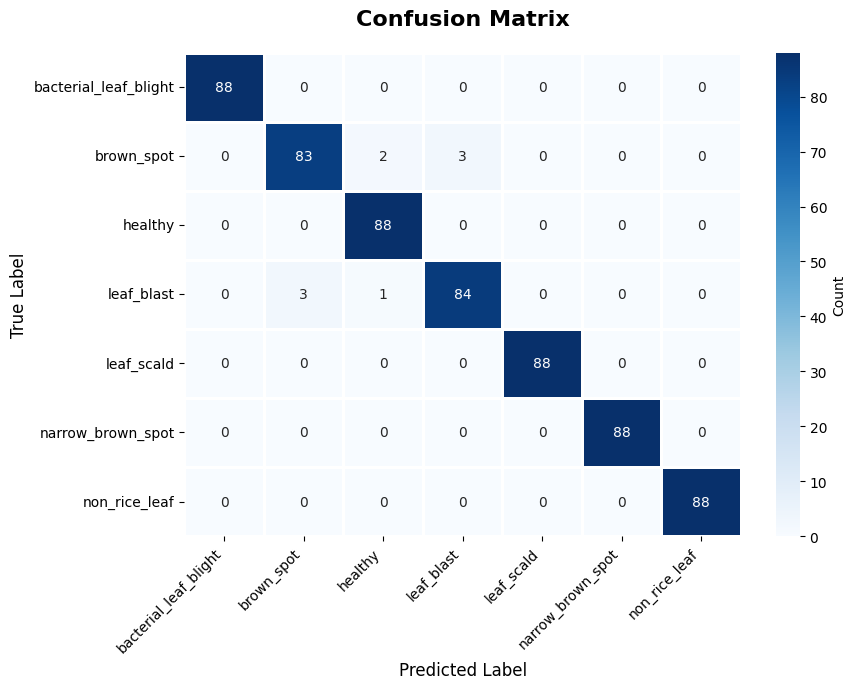

In [51]:
print("\n" + "="*60)
print("CLASSIFICATION REPORT")
print("="*60)
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(max(8, NUM_CLASSES + 2), max(6, NUM_CLASSES)))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Count'}, linewidths=1)
plt.title('Confusion Matrix', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('True Label', fontsize=12); plt.xlabel('Predicted Label', fontsize=12)
plt.xticks(rotation=45, ha='right'); plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(save_dir, 'confusion_matrix.png'), dpi=300)
plt.show()

In [47]:
print("\n" + "="*60)
print("PER-CLASS ACCURACY")
print("="*60)
per_class_acc = cm.diagonal() / cm.sum(axis=1)
for cls, acc in zip(class_names, per_class_acc):
    bar = '\u2588' * int(acc * 40)
    print(f"{cls:<30} {acc*100:5.1f}% {bar}")
print("="*60)
print(f"{'AVERAGE':<30} {per_class_acc.mean()*100:5.1f}%")
print("="*60)


PER-CLASS ACCURACY
bacterial_leaf_blight          100.0% ████████████████████████████████████████
brown_spot                      94.3% █████████████████████████████████████
healthy                        100.0% ████████████████████████████████████████
leaf_blast                      95.5% ██████████████████████████████████████
leaf_scald                     100.0% ████████████████████████████████████████
narrow_brown_spot              100.0% ████████████████████████████████████████
non_rice_leaf                  100.0% ████████████████████████████████████████
AVERAGE                         98.5%
